# Desafío 4

Alumno: Rodrigo Mesa Marchi (a2016)

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## LSTM Traductor


In [ ]:
import re
import os
import pandas as pd
import torch.nn.functional as F
import spacy
import torch
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from spacy.symbols import ORTH
import json 
import numpy as np
import pickle
import torch.nn as nn
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

/home/rodri/Documents/Maestria/proyectos_maestria/procesamiento_lenguaje/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Descargar la carpeta de dataset

if os.access('spa-eng', os.F_OK) is False:
    if os.access('spa-eng.zip', os.F_OK) is False:
        !curl -L -o 'spa-eng.zip' 'http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip'
    !unzip -q spa-eng.zip 
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [2]:
MAX_NUM_SENTENCES = 50000

In [6]:
#MAX_INPUT_LEN = 20  # o el límite que quieras
#MAX_OUTPUT_LEN = 25

# Tokens especiales y parámetros
MAX_VOCAB_SIZE = 8000
# Por limitaciones de RAM no se leen todas las filas

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

In [7]:
df = pd.read_csv("./spa-eng/spa.txt", sep='\t', names=["input", "output"])
df["output_sentence"] = df["output"] + f' {EOS_TOKEN}'
df["output_sentence_input"] = f'{SOS_TOKEN} ' + df["output"]
#df = df.sample(n = MAX_NUM_SENTENCES)
input_sentences = df["input"].to_list()
output_sequence = df["output_sentence"].to_list()
output_sequence_input = df["output_sentence_input"].to_list()

In [8]:
# Cargar modelos spaCy
spacy_eng = spacy.load("en_core_web_sm")
spacy_esp = spacy.load("es_core_news_sm")


special_tokens = [SOS_TOKEN, EOS_TOKEN]

for token in special_tokens:
    spacy_esp.tokenizer.add_special_case(token, [{ORTH: token}])


def tokenize_spacy_pipe(sentences, nlp):
    return [[token.text.lower() for token in doc] for doc in nlp.pipe(sentences, batch_size=64)]





input_tokenized = tokenize_spacy_pipe(input_sentences, spacy_eng)
output_tokenized_input = tokenize_spacy_pipe(output_sequence_input, spacy_esp)  # con <sos>
output_tokenized_target = tokenize_spacy_pipe(output_sequence, spacy_esp)       # con <eos>


## Antes de convertir tokens a ids, limita los tokens (en formato string)
#input_tokenized = [seq[:MAX_INPUT_LEN] for seq in input_tokenized]

#output_tokenized_input = [truncate_sequence_with_special_tokens(seq, MAX_OUTPUT_LEN, sos_token=SOS_TOKEN, eos_token=None) 
#                          for seq in output_tokenized_input]

#output_tokenized_target = [truncate_sequence_with_special_tokens(seq, MAX_OUTPUT_LEN, sos_token=None, eos_token=EOS_TOKEN) 
#                           for seq in output_tokenized_target]

# --- 2. Construir vocabularios ---
def build_vocab(tokenized_sentences, max_vocab_size):
    PAD_TOKEN = "<pad>"
    UNK_TOKEN = "<unk>"
    SOS_TOKEN = "<sos>"
    EOS_TOKEN = "<eos>"
    
    # Contar tokens
    counter = Counter(token for sentence in tokenized_sentences for token in sentence)
    most_common = counter.most_common(max_vocab_size - 4)  # reservar 4 para los tokens especiales
    
    # Diccionario palabra → índice
    word2idx = {
        PAD_TOKEN: 0,
        UNK_TOKEN: 1,
        SOS_TOKEN: 2,
        EOS_TOKEN: 3
    }
    
    # Añadir palabras del vocabulario empezando desde el índice 4
    for i, (word, _) in enumerate(most_common, start=4):
        if word not in word2idx:  # evitar sobrescribir los especiales
            word2idx[word] = i
    
    # Diccionario inverso
    idx2word = {idx: word for word, idx in word2idx.items()}
    
    return word2idx, idx2word

# Para el vocabulario de input (inglés)
word2idx_input, idx2word_input = build_vocab(input_tokenized, MAX_VOCAB_SIZE)
# Para el vocabulario de output (español), junto input y target para vocab completo
word2idx_output, idx2word_output = build_vocab(output_tokenized_input + output_tokenized_target, MAX_VOCAB_SIZE)

# --- 3. Pasar tokens a ids ---
def tokens_to_ids(tokenized_sentences, word2idx):
    return [
        torch.tensor([word2idx.get(token, word2idx[UNK_TOKEN]) for token in sentence], dtype=torch.long)
        for sentence in tokenized_sentences
    ]

encoder_sequences = tokens_to_ids(input_tokenized, word2idx_input)
decoder_input_sequences = tokens_to_ids(output_tokenized_input, word2idx_output)
decoder_target_sequences = tokens_to_ids(output_tokenized_target, word2idx_output)

# --- 4. Padding con PyTorch ---
encoder_padded = pad_sequence(encoder_sequences, batch_first=True, padding_value=word2idx_input[PAD_TOKEN], padding_side='left')
decoder_input_padded = pad_sequence(decoder_input_sequences, batch_first=True, padding_value=word2idx_output[PAD_TOKEN],padding_side='right')
decoder_target_padded = pad_sequence(decoder_target_sequences, batch_first=True, padding_value=word2idx_output[PAD_TOKEN],padding_side='right')

# --- 5. Mostrar resultados ---
print("encoder_padded shape:", encoder_padded.shape)
print("decoder_input_padded shape:", decoder_input_padded.shape)
print("decoder_target_padded shape:", decoder_target_padded.shape)

# Ejemplo
i = 0
print("\nEjemplo frase input original:", input_sentences[i])
print("Tokenizada:", input_tokenized[i])
print("Indexada:", encoder_sequences[i])
print("Padded:", encoder_padded[i])

print("\nEjemplo frase output_input (con <sos>):", output_sequence_input[i])
print("Tokenizada:", output_tokenized_input[i])
print("Indexada:", decoder_input_sequences[i])
print("Padded:", decoder_input_padded[i])

print("\nEjemplo frase output_target (con <eos>):", output_sequence[i])
print("Tokenizada:", output_tokenized_target[i])
print("Indexada:", decoder_target_sequences[i])
print("Padded:", decoder_target_padded[i])


# Guardar tensores PyTorch
torch.save(encoder_padded, "encoder_padded.pt")
torch.save(decoder_input_padded, "decoder_input_padded.pt")
torch.save(decoder_target_padded, "decoder_target_padded.pt")

# Guardar vocabularios como JSON
with open("word2idx_input.json", "w", encoding="utf-8") as f:
    json.dump(word2idx_input, f, ensure_ascii=False)

with open("idx2word_input.json", "w", encoding="utf-8") as f:
    json.dump(idx2word_input, f, ensure_ascii=False)

with open("word2idx_output.json", "w", encoding="utf-8") as f:
    json.dump(word2idx_output, f, ensure_ascii=False)

with open("idx2word_output.json", "w", encoding="utf-8") as f:
    json.dump(idx2word_output, f, ensure_ascii=False)

encoder_padded shape: torch.Size([118964, 49])
decoder_input_padded shape: torch.Size([118964, 52])
decoder_target_padded shape: torch.Size([118964, 52])

Ejemplo frase input original: Go.
Tokenizada: ['go', '.']
Indexada: tensor([50,  4])
Padded: tensor([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 50,  4])

Ejemplo frase output_input (con <sos>): <sos> Ve.
Tokenizada: ['<sos>', 've', '.']
Indexada: tensor([  2, 376,   4])
Padded: tensor([  2, 376,   4,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0])

Ejemplo frase output_target (con <eos>): Ve. <eos>
Tokenizada: ['ve', '.', '<eos>']
Indexada: tensor([376,   4,

In [38]:
# Cargar tensores PyTorch
encoder_padded = torch.load("encoder_padded.pt")
decoder_input_padded = torch.load("decoder_input_padded.pt")
decoder_target_padded = torch.load("decoder_target_padded.pt")

# Cargar vocabularios desde archivos JSON
with open("word2idx_input.json", "r", encoding="utf-8") as f:
    word2idx_input = json.load(f)

with open("idx2word_input.json", "r", encoding="utf-8") as f:
    idx2word_input = json.load(f)

with open("word2idx_output.json", "r", encoding="utf-8") as f:
    word2idx_output = json.load(f)

with open("idx2word_output.json", "r", encoding="utf-8") as f:
    idx2word_output = json.load(f)

In [10]:
len(word2idx_output)

7998

In [22]:
MAX_INPUT_LEN= encoder_padded.shape[1]
MAX_OUTPUT_LEN= decoder_target_padded.shape[1]

In [12]:
decoder_target_padded.max()

tensor(7999)

In [13]:
num_classes = min(len(word2idx_output)+2, MAX_VOCAB_SIZE)

In [ ]:
#decoder_targets_onehot = F.one_hot(decoder_target_padded, num_classes=num_classes)

# Esto genera un tensor de shape (batch_size, seq_len, num_words_output), tipo torch.LongTensor
#print(decoder_targets_onehot.shape)

torch.Size([7000, 25, 6318])


In [96]:
# Descargar los embeddings desde un google drive (es la forma más rápida)
# NOTA: No hay garantía de que estos links perduren, en caso de que no estén
# disponibles descargar de la página oficial como se explica en el siguiente bloque de código
import os
import gdown
if os.access('gloveembedding.pkl', os.F_OK) is False:
    url = 'https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&export=download'
    output = 'gloveembedding.pkl'
    gdown.download(url, output, quiet=False)
else:
    print("Los embeddings gloveembedding.pkl ya están descargados")

Downloading...
From (original): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&export=download
From (redirected): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&export=download&confirm=t&uuid=daae3613-2231-4021-b771-2a179d001e14
To: /home/rodri/Documents/Maestria/proyectos_maestria/procesamiento_lenguaje/gloveembedding.pkl
100%|██████████| 525M/525M [00:47<00:00, 11.0MB/s] 


In [14]:
PKL_PATH = 'gloveembedding.pkl'

# === Cargar los embeddings desde el .pkl ===
with open(PKL_PATH, 'rb') as f:
    embeddings = pickle.load(f)  # np.recarray

embed_dim = embeddings['embedding'].shape[1]
word_to_vec = {word: vec for word, vec in zip(embeddings['word'], embeddings['embedding'])}

# === Crear la embedding matrix para el vocabulario ===
print('Preparing embedding matrix...')

nb_words = min(MAX_VOCAB_SIZE, len(word2idx_input))
embedding_matrix = np.zeros((nb_words, embed_dim), dtype=np.float32)
words_not_found = []

for word, idx in word2idx_input.items():
    if idx >= nb_words:
        continue
    vec = word_to_vec.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
    else:
        words_not_found.append(word)

# === Información útil ===
num_null = np.sum(np.sum(embedding_matrix**2, axis=1) == 0)
print(f'Number of null word embeddings: {num_null}')
print(f'Words not found: {len(words_not_found)}')

# === Convertir a tensor PyTorch para usar en nn.Embedding ===
embedding_tensor = torch.tensor(embedding_matrix)
embedding_layer = torch.nn.Embedding.from_pretrained(embedding_tensor, freeze=True)

Preparing embedding matrix...
Number of null word embeddings: 127
Words not found: 127


In [6]:
word2idx_input

{'<pad>': 0,
 '<unk>': 1,
 '<sos>': 2,
 '<eos>': 3,
 '.': 4,
 'i': 5,
 'the': 6,
 'to': 7,
 'you': 8,
 'tom': 9,
 'a': 10,
 '?': 11,
 'is': 12,
 "n't": 13,
 'do': 14,
 'he': 15,
 'it': 16,
 "'s": 17,
 'in': 18,
 'of': 19,
 'that': 20,
 'was': 21,
 ',': 22,
 'have': 23,
 'me': 24,
 'this': 25,
 'my': 26,
 'we': 27,
 'for': 28,
 'she': 29,
 'what': 30,
 'are': 31,
 'mary': 32,
 'his': 33,
 'your': 34,
 'did': 35,
 'on': 36,
 'be': 37,
 'not': 38,
 'with': 39,
 'want': 40,
 "'m": 41,
 'at': 42,
 'and': 43,
 'like': 44,
 'know': 45,
 'him': 46,
 'can': 47,
 'there': 48,
 'go': 49,
 'they': 50,
 'her': 51,
 'has': 52,
 "'re": 53,
 'time': 54,
 'will': 55,
 'how': 56,
 'does': 57,
 'as': 58,
 'had': 59,
 "'ll": 60,
 'all': 61,
 'up': 62,
 'very': 63,
 'about': 64,
 'here': 65,
 'think': 66,
 'would': 67,
 'get': 68,
 "'ve": 69,
 'when': 70,
 'ca': 71,
 'out': 72,
 'from': 73,
 'were': 74,
 'if': 75,
 'one': 76,
 'no': 77,
 'an': 78,
 'by': 79,
 'going': 80,
 'could': 81,
 'who': 82,
 'come':

In [11]:
embedding_matrix

array([[ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       ...,
       [ 1.1965  , -0.52182 ,  0.90006 , ...,  0.15488 , -0.33233 ,
        -0.20695 ],
       [ 0.3462  ,  0.43466 ,  0.1917  , ..., -0.18851 , -0.25349 ,
         0.084514],
       [-0.16342 , -0.84229 , -0.35139 , ...,  0.80577 ,  0.12589 ,
         0.72663 ]], shape=(8000, 50), dtype=float32)

In [77]:
import torch
import torch.nn as nn

class TranslateModel(L.LightningModule):
    def __init__(self, 
                 embedding_matrix,
                 num_words_output,
                 embed_dim,
                 n_units,
                 max_input_len,
                 max_out_len,
                 lr=1e-3):
        super().__init__()
        self.save_hyperparameters()

        self.encoder_embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=True
        )

        self.encoder_lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=n_units,
            batch_first=True
        )

        self.decoder_embedding = nn.Embedding(
            num_embeddings=num_words_output,
            embedding_dim=n_units
        )

        self.decoder_lstm = nn.LSTM(
            input_size=n_units,
            hidden_size=n_units,
            batch_first=True
        )

        self.fc = nn.Linear(n_units, num_words_output)
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=0)  # 0 = padding
        self.lr = lr
    def forward(self, encoder_input_ids, decoder_input_ids):
        # === Encoder ===
        encoder_embedded = self.encoder_embedding(encoder_input_ids)  # (batch, seq_len, embed_dim)
        encoder_outputs, (h, c) = self.encoder_lstm(encoder_embedded)

        # === Decoder ===
        decoder_embedded = self.decoder_embedding(decoder_input_ids)  # (batch, seq_len, n_units)
        decoder_outputs, _ = self.decoder_lstm(decoder_embedded, (h, c))  # initial_state = encoder's final states

        # === Output ===
        output = self.fc(decoder_outputs)  # (batch, seq_len, num_words_output)
        return output



    def training_step(self, batch, batch_idx):
        encoder_input, decoder_input, decoder_target = batch
        logits = self(encoder_input, decoder_input)
        loss = self.loss_fn(logits.view(-1, logits.size(-1)), decoder_target.view(-1))
        # 👇 esto loggea al trainer automáticamente
        self.log_dict(
            {"train_loss": loss},
            on_step=False, on_epoch=True, prog_bar=True, logger=True
        )
        return loss

    def validation_step(self, batch, batch_idx):
        encoder_input, decoder_input, decoder_target = batch
        logits = self(encoder_input, decoder_input)
        loss = self.loss_fn(logits.view(-1, logits.size(-1)), decoder_target.view(-1))
        self.log_dict(
            {"val_loss": loss,},
            on_step=False, on_epoch=True, prog_bar=True, logger=True
        )


    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

    def predict_step(self, batch, batch_idx, **kwargs):
        encoder_input, _, _ = batch
        return self.generate(encoder_input)

    import torch

    def generate(
        self,
        encoder_input_ids,
        sos_token_id=2,
        eos_token_id=3,
        max_len=None,
        pad_token_id=0,
        return_trimmed=True,   # recorta cada secuencia al primer <eos> (incluido)
    ):
        if max_len is None:
            max_len = self.hparams.max_out_len

        batch_size = encoder_input_ids.size(0)
        device = encoder_input_ids.device

        # Encode
        encoder_embedded = self.encoder_embedding(encoder_input_ids)
        _, (h, c) = self.encoder_lstm(encoder_embedded)

        # Primer input del decoder: <sos>
        decoder_input = torch.full(
            (batch_size, 1), sos_token_id, dtype=torch.long, device=device
        )

        outputs = []
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

        for _ in range(max_len):
            # Paso del decoder
            decoder_embedded = self.decoder_embedding(decoder_input)  # (B,1,E)
            decoder_output, (h, c) = self.decoder_lstm(decoder_embedded, (h, c))
            logits = self.fc(decoder_output[:, -1, :])                # (B,V)

            # Greedy
            next_tokens = torch.argmax(logits, dim=-1)                # (B,)

            # Para ejemplos ya terminados, mantené el token de entrada en <eos>
            # (no cambiamos su estado de "finished")
            next_tokens = torch.where(
                finished, torch.tensor(eos_token_id, device=device), next_tokens
            )

            # Guardar salida de este paso.
            # Para no “ensuciar” con <eos> repetidos, escribimos PAD en posiciones ya terminadas
            token_to_write = torch.where(
                finished, torch.tensor(pad_token_id, device=device), next_tokens
            )
            outputs.append(token_to_write.unsqueeze(1))               # (B,1)

            # Actualizar mask de terminación
            finished = finished | (next_tokens == eos_token_id)

            # Siguiente entrada del decoder
            decoder_input = next_tokens.unsqueeze(1)

            # Corta temprano si todos terminaron
            if finished.all():
                break

        # (B, T_gen)
        outputs = torch.cat(outputs, dim=1) if outputs else torch.empty(
            batch_size, 0, dtype=torch.long, device=device
        )

        if return_trimmed:
            # Recorta cada fila hasta el primer <eos> (incluyéndolo).
            trimmed = []
            for i in range(batch_size):
                row = torch.cat([outputs[i]])  # 1D
                eos_pos = (row == eos_token_id).nonzero(as_tuple=False)
                end = eos_pos[0].item() + 1 if eos_pos.numel() > 0 else row.size(0)
                trimmed.append(row[:end])
            return trimmed  # lista de tensores 1D de longitudes variables
        else:
            # Si querés forma rectangular, devolvé padded (ya tiene PAD donde terminó).
            # Si el loop cortó antes de max_len, completamos al tope con PAD.
            if outputs.size(1) < max_len:
                pad_len = max_len - outputs.size(1)
                pad = torch.full(
                    (batch_size, pad_len), pad_token_id, dtype=torch.long, device=device
                )
                outputs = torch.cat([outputs, pad], dim=1)
            return outputs





In [78]:
from torch.utils.data import Dataset

class TranslationDataset(Dataset):
    def __init__(self, encoder_inputs, decoder_inputs, decoder_targets):
        self.encoder_inputs = encoder_inputs  # (num_samples, max_input_len)
        self.decoder_inputs = decoder_inputs  # (num_samples, max_output_len)
        self.decoder_targets = decoder_targets

    def __len__(self):
        return len(self.encoder_inputs)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.encoder_inputs[idx], dtype=torch.long),
            torch.tensor(self.decoder_inputs[idx], dtype=torch.long),
            torch.tensor(self.decoder_targets[idx], dtype=torch.long)
        )

In [79]:
num_words_output = min(MAX_VOCAB_SIZE+3, len(word2idx_output)+3)  # o +k si añadís especiales ahora

In [80]:
from torch.utils.data import DataLoader, random_split
from lightning.pytorch.loggers import CSVLogger

csv_logger = CSVLogger(save_dir="logs", name="seq2seq")  # logs/seq2seq/version_0/metrics.csv
# Preparar datos
dataset = TranslationDataset(encoder_padded, decoder_input_padded, decoder_target_padded)


early_stop = EarlyStopping(
    monitor="val_loss",   # must match your logged key
    mode="min",           # "min" because lower val_loss is better
    patience=3,           # epochs with no improvement before stopping
    min_delta=0.0,        # minimum change to qualify as an improvement
)

ckpt = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,         # keep the best checkpoint
    filename="best-{epoch:02d}-{val_loss:.4f}",
)


train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

# Crear modelo
model = TranslateModel(
    embedding_matrix=torch.tensor(embedding_matrix),
    num_words_output=num_words_output,
    embed_dim=embed_dim,
    n_units=128,
    max_input_len=MAX_INPUT_LEN,
    max_out_len=MAX_OUTPUT_LEN,
    lr=1e-3
)

# Entrenar
trainer = L.Trainer(
    max_epochs=30,
    accelerator="auto",
    devices="auto",
    logger=csv_logger,
    log_every_n_steps=10,
    callbacks=[early_stop, ckpt],
)
trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name              | Type             | Params | Mode 
---------------------------------------------------------------
0 | encoder_embedding | Embedding        | 400 K  | train
1 | encoder_lstm      | LSTM             | 92.2 K | train
2 | decoder_embedding | Embedding        | 1.0 M  | train
3 | decoder_lstm      | LSTM             | 132 K  | train
4 | fc                | Linear           | 1.0 M  | train
5 | loss_fn           | CrossEntropyLoss | 0      | train
---------------------------------------------------------------
2.3 M     Trainable params
400 K     Non-trainable params
2.7 M     Total params
10.722    Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode


/home/rodri/Documents/Maestria/proyectos_maestria/procesamiento_lenguaje/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/tmp/ipykernel_12202/1396719371.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.encoder_inputs[idx], dtype=torch.long),
/tmp/ipykernel_12202/1396719371.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.decoder_inputs[idx], dtype=torch.long),
/tmp/ipykernel_12202/1396719371.py:16: Use

Epoch 13: 100%|██████████| 2975/2975 [00:20<00:00, 144.79it/s, v_num=7, val_loss=1.920, train_loss=1.140]


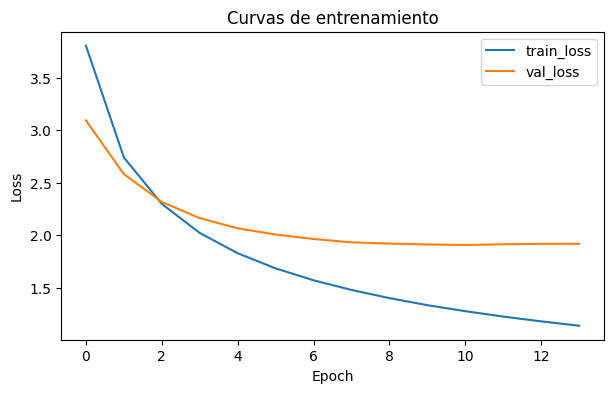

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def load_csv_metrics(log_dir="logs/seq2seq"):
    versions = sorted(Path(log_dir).glob("version_*"), key=lambda p: int(p.name.split("_")[-1]))
    assert versions, f"No hay versiones en {log_dir}"
    df = pd.read_csv(versions[-1] / "metrics.csv")
    return df

df = load_csv_metrics()

# Curvas por época (Lightning guarda varias filas por step → usamos el último por epoch)
plt.figure(figsize=(7,4))
df.groupby("epoch")["train_loss"].last().plot(label="train_loss")
df.groupby("epoch")["val_loss"].last().plot(label="val_loss")
plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Curvas de entrenamiento"); plt.show()

In [82]:
def output_to_text(res, idx2word_output):
    lista_traduccion = []
    for sentence in res:
        frase = []
        for word in sentence:
            frase.append(idx2word_output[int(word)])
        lista_traduccion.append(frase)
    return lista_traduccion

In [123]:
N = encoder_padded.size(0)
indices = torch.randint(0, N, (5,))  # 10 random indices
input_encoder_sequences = encoder_padded[indices]


test_input_padded = pad_sequence(input_encoder_sequences, batch_first=True, padding_value=word2idx_input[PAD_TOKEN], padding_side='left')
res = model.generate(test_input_padded,sos_token_id=2, eos_token_id=3)

In [124]:
# Select from list using the same indices
input_encoder_raw = [encoder_sequences[i] for i in indices.tolist()]
frases_ingles = output_to_text(res=input_encoder_raw, idx2word_output=idx2word_input)

In [125]:
frases_espanol = output_to_text(res=res, idx2word_output=idx2word_output)

In [126]:
for frase_ingles, frase_espanol in zip(frases_ingles, frases_espanol):
    print("-"*100)
    print("Frase original: ", frase_ingles)
    print("Frase traducida: ", frase_espanol)

----------------------------------------------------------------------------------------------------
Frase original:  ['i', 'want', 'to', 'play', '.']
Frase traducida:  ['quiero', 'jugar', '.', '<eos>']
----------------------------------------------------------------------------------------------------
Frase original:  ['i', 'think', 'you', "'ll", 'find', 'it', 'very', 'interesting', '.']
Frase traducida:  ['creo', 'que', 'lo', 'encontrarás', 'muy', 'interesante', '.', '<eos>']
----------------------------------------------------------------------------------------------------
Frase original:  ['it', 'leaves', 'every', 'thirty', 'minutes', '.']
Frase traducida:  ['casi', '<unk>', 'cada', 'treinta', 'minutos', '.', '<eos>']
----------------------------------------------------------------------------------------------------
Frase original:  ['just', 'say', 'yes', '.']
Frase traducida:  ['nomás', 'di', 'que', 'sí', '.', '<eos>']
------------------------------------------------------------